In [ ]:
import os
import shutil
import random
from pathlib import Path

# Set base input and output folders
base_input_dir = '/content/drive/MyDrive/Hands40_All'
output_base_dir = '/content/drive/MyDrive/Hands40'  # Will create train/val/test folders here

# Split ratios
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

# Ensure reproducibility
random.seed(42)

# Create output folders
for split in ['train', 'val', 'test']:
    os.makedirs(os.path.join(output_base_dir, split), exist_ok=True)

# Loop through each class
for class_name in os.listdir(base_input_dir):
    class_path = os.path.join(base_input_dir, class_name)
    if not os.path.isdir(class_path):
        continue

    # Get all images in class
    images = os.listdir(class_path)
    random.shuffle(images)

    # Split
    n_total = len(images)
    n_train = int(n_total * train_ratio)
    n_val = int(n_total * val_ratio)

    train_images = images[:n_train]
    val_images = images[n_train:n_train+n_val]
    test_images = images[n_train+n_val:]

    # Copy to new folders
    for split_name, split_images in zip(['train', 'val', 'test'],
                                        [train_images, val_images, test_images]):
        split_dir = os.path.join(output_base_dir, split_name, class_name)
        os.makedirs(split_dir, exist_ok=True)

        for img_name in split_images:
            src = os.path.join(class_path, img_name)
            dst = os.path.join(split_dir, img_name)
            shutil.copy2(src, dst)

print("✅ Dataset successfully split into train/val/test.")


In [4]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# ---------------------
# 🔧 Data Preparation
# ---------------------
train_dir = '/content/drive/MyDrive/Hands40/train'
val_dir = '/content/drive/MyDrive/Hands40/val'
test_dir = '/content/drive/MyDrive/Hands40/test'

image_size = (224, 224)
batch_size = 32

ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    shear_range=0.2,
    brightness_range=[0.8, 1.2],
    horizontal_flip=True,
    fill_mode='nearest'
)


val_test_gen = ImageDataGenerator(rescale=1./255)

from os import listdir

class_list = sorted(listdir(train_dir))  # List of class folder names

train_data = train_gen.flow_from_directory(
    train_dir, target_size=image_size, class_mode='categorical',
    batch_size=batch_size, shuffle=True, classes=class_list
)
val_data = val_test_gen.flow_from_directory(
    val_dir, target_size=image_size, class_mode='categorical',
    batch_size=batch_size, shuffle=False, classes=class_list
)
test_data = val_test_gen.flow_from_directory(
    test_dir, target_size=image_size, class_mode='categorical',
    batch_size=batch_size, shuffle=False, classes=class_list
)


num_classes = train_data.num_classes

# ---------------------
# 🧠 VGG16 Model
# ---------------------
base_model = VGG16(include_top=False, weights='imagenet', input_shape=(224, 224, 3))

for layer in base_model.layers:
    layer.trainable = True

# Add classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(optimizer = tf.keras.optimizers.Adam(learning_rate=1e-5),
              loss = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
              metrics=['accuracy'])

# ---------------------
# 📈 Training
# ---------------------
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, verbose=1),
    tf.keras.callbacks.ModelCheckpoint('best_vgg16_model.h5', save_best_only=True)
]

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=50,
    callbacks=callbacks
)


Found 818 images belonging to 40 classes.
Found 159 images belonging to 40 classes.
Found 220 images belonging to 40 classes.
Epoch 1/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 861ms/step - accuracy: 0.0216 - loss: 3.8507

26/26 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.0217 - loss: 3.8502 - val_accuracy: 0.0314 - val_loss: 3.7054 - learning_rate: 1.0000e-05
Epoch 2/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 774ms/step - accuracy: 0.0337 - loss: 3.7843

26/26 ━━━━━━━━━━━━━━━━━━━━ 23s 860ms/step - accuracy: 0.0337 - loss: 3.7834 - val_accuracy: 0.0818 - val_loss: 3.6403 - learning_rate: 1.0000e-05
Epoch 3/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 775ms/step - accuracy: 0.0544 - loss: 3.7080

26/26 ━━━━━━━━━━━━━━━━━━━━ 41s 870ms/step - accuracy: 0.0545 - loss: 3.7070 - val_accuracy: 0.1635 - val_loss: 3.5637 - learning_rate: 1.0000e-05
Epoch 4/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 770ms/step - accuracy: 0.0658 - loss: 3.6246

26/26 ━━━━━━━━━━━━━━━━━━━━ 22s 858ms/step - accuracy: 0.0664 - loss: 3.6234 - val_accuracy: 0.1761 - val_loss: 3.4265 - learning_rate: 1.0000e-05
Epoch 5/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 738ms/step - accuracy: 0.1218 - loss: 3.4826

...

26/26 ━━━━━━━━━━━━━━━━━━━━ 22s 848ms/step - accuracy: 0.8644 - loss: 1.2872 - val_accuracy: 0.9497 - val_loss: 1.0874 - learning_rate: 1.0000e-05
Epoch 40/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 752ms/step - accuracy: 0.8590 - loss: 1.2847

26/26 ━━━━━━━━━━━━━━━━━━━━ 22s 854ms/step - accuracy: 0.8594 - loss: 1.2842 - val_accuracy: 0.9497 - val_loss: 1.0513 - learning_rate: 1.0000e-05
Epoch 41/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 21s 784ms/step - accuracy: 0.8613 - loss: 1.2662 - val_accuracy: 0.8868 - val_loss: 1.1417 - learning_rate: 1.0000e-05
Epoch 42/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 22s 841ms/step - accuracy: 0.8652 - loss: 1.2536 - val_accuracy: 0.9434 - val_loss: 1.1064 - learning_rate: 1.0000e-05
Epoch 43/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 741ms/step - accuracy: 0.8859 - loss: 1.2197
Epoch 43: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.
26/26 ━━━━━━━━━━━━━━━━━━━━ 22s 844ms/step - accuracy: 0.8861 - loss: 1.2195 - val_accuracy: 0.9182 - val_loss: 1.0708 - learning_rate: 1.0000e-05
Epoch 44/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 743ms/step - accuracy: 0.8956 - loss: 1.1586

26/26 ━━━━━━━━━━━━━━━━━━━━ 22s 832ms/step - accuracy: 0.8959 - loss: 1.1584 - val_accuracy: 0.9434 - val_loss: 1.0367 - learning_rate: 2.0000e-06
Epoch 45/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 732ms/step - accuracy: 0.9289 - loss: 1.1171

26/26 ━━━━━━━━━━━━━━━━━━━━ 42s 860ms/step - accuracy: 0.9289 - loss: 1.1172 - val_accuracy: 0.9497 - val_loss: 1.0340 - learning_rate: 2.0000e-06
Epoch 46/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 735ms/step - accuracy: 0.9290 - loss: 1.0993

26/26 ━━━━━━━━━━━━━━━━━━━━ 22s 821ms/step - accuracy: 0.9291 - loss: 1.0994 - val_accuracy: 0.9560 - val_loss: 1.0024 - learning_rate: 2.0000e-06
Epoch 47/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 22s 836ms/step - accuracy: 0.9067 - loss: 1.1279 - val_accuracy: 0.9434 - val_loss: 1.0086 - learning_rate: 2.0000e-06
Epoch 48/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 23s 859ms/step - accuracy: 0.9284 - loss: 1.1087 - val_accuracy: 0.9497 - val_loss: 1.0113 - learning_rate: 2.0000e-06
Epoch 49/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 787ms/step - accuracy: 0.9360 - loss: 1.0822
Epoch 49: ReduceLROnPlateau reducing learning rate to 3.999999989900971e-07.
26/26 ━━━━━━━━━━━━━━━━━━━━ 41s 856ms/step - accuracy: 0.9359 - loss: 1.0828 - val_accuracy: 0.9623 - val_loss: 1.0084 - learning_rate: 2.0000e-06
Epoch 50/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 23s 871ms/step - accuracy: 0.9401 - loss: 1.1023 - val_accuracy: 0.9497 - val_loss: 1.0049 - learning_rate: 4.0000e-07


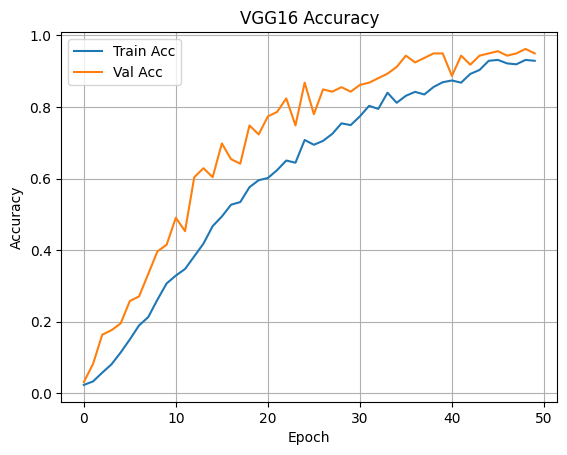

In [5]:
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('VGG16 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [7]:
test_loss, test_acc = model.evaluate(test_data)
print(f"✅ Final Test Accuracy: {test_acc:.4f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 375ms/step - accuracy: 0.9587 - loss: 1.0344
✅ Final Test Accuracy: 0.9409


7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 295ms/step


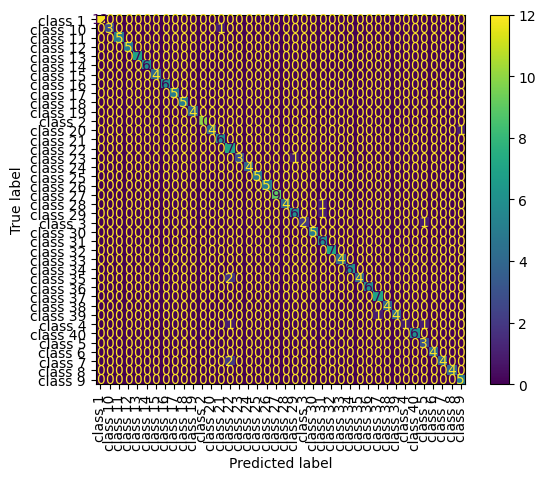

In [8]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predict on test data
y_true = test_data.classes
y_pred = np.argmax(model.predict(test_data), axis=1)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=test_data.class_indices.keys())
disp.plot(xticks_rotation='vertical')


In [56]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from os import listdir

train_dir = '/content/drive/MyDrive/Hands40/train'
val_dir = '/content/drive/MyDrive/Hands40/val'
test_dir = '/content/drive/MyDrive/Hands40/test'

import os

base_path = '/content/drive/MyDrive/Hands40'  # adjust as needed

for split in ['train', 'val', 'test']:
    split_path = os.path.join(base_path, split)
    for folder in os.listdir(split_path):
        old_path = os.path.join(split_path, folder)
        if os.path.isdir(old_path):
            # Extract number from folder name (no matter how many "class_" prefixes)
            parts = folder.split('_')
            number = parts[-1].zfill(3)  # Use last part only
            new_folder = f'class_{number}'
            new_path = os.path.join(split_path, new_folder)
            if old_path != new_path:
                os.rename(old_path, new_path)


classes = sorted(listdir(train_dir))  # Ensure consistent class indices

image_size = (224, 224)
batch_size = 32

train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

val_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.05,
    horizontal_flip=True
)


train_data = train_gen.flow_from_directory(
    train_dir, classes=classes, target_size=image_size,
    batch_size=batch_size, class_mode='categorical', shuffle=True
)

val_data = val_gen.flow_from_directory(
    val_dir, classes=classes, target_size=image_size,
    batch_size=batch_size, class_mode='categorical', shuffle=False
)

test_data = val_gen.flow_from_directory(
    test_dir, classes=classes, target_size=image_size,
    batch_size=batch_size, class_mode='categorical', shuffle=False
)

num_classes = len(classes)


Found 818 images belonging to 40 classes.
Found 159 images belonging to 40 classes.
Found 220 images belonging to 40 classes.


In [57]:
from os import listdir
print(sorted(listdir(train_dir)))

print(train_data.class_indices)
print(train_data.labels[:10])
print(train_data.class_indices == val_data.class_indices)


['class_001', 'class_002', 'class_003', 'class_004', 'class_005', 'class_006', 'class_007', 'class_008', 'class_009', 'class_010', 'class_011', 'class_012', 'class_013', 'class_014', 'class_015', 'class_016', 'class_017', 'class_018', 'class_019', 'class_020', 'class_021', 'class_022', 'class_023', 'class_024', 'class_025', 'class_026', 'class_027', 'class_028', 'class_029', 'class_030', 'class_031', 'class_032', 'class_033', 'class_034', 'class_035', 'class_036', 'class_037', 'class_038', 'class_039', 'class_040']
{'class_001': 0, 'class_002': 1, 'class_003': 2, 'class_004': 3, 'class_005': 4, 'class_006': 5, 'class_007': 6, 'class_008': 7, 'class_009': 8, 'class_010': 9, 'class_011': 10, 'class_012': 11, 'class_013': 12, 'class_014': 13, 'class_015': 14, 'class_016': 15, 'class_017': 16, 'class_018': 17, 'class_019': 18, 'class_020': 19, 'class_021': 20, 'class_022': 21, 'class_023': 22, 'class_024': 23, 'class_025': 24, 'class_026': 25, 'class_027': 26, 'class_028': 27, 'class_029':

In [58]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy

# Load base model
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

for layer in base_model.layers:
    layer.trainable = True

# Add custom classification head
x = base_model.output
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

# Compile
from tensorflow.keras.metrics import TopKCategoricalAccuracy

model.compile(
    optimizer=Adam(1e-4),
    loss=CategoricalCrossentropy(label_smoothing=0.05),
    metrics=['accuracy', TopKCategoricalAccuracy(k=3, name='top_3_acc')]
)


In [59]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# STEP 1: Compute class weights
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_data.classes),
    y=train_data.classes
)
class_weights = dict(enumerate(class_weights_array))

# STEP 2: Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5, verbose=1),
    ModelCheckpoint('resnet50_hand_model.keras', save_best_only=True)
]

# STEP 3: Train the model with class weights
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=30,
    class_weight=class_weights,
    callbacks=callbacks
)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 118s 2s/step - accuracy: 0.0247 - loss: 4.2267 - val_accuracy: 0.0189 - val_loss: 4.1021 - learning_rate: 1.0000e-05
Epoch 2/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - accuracy: 0.0402 - loss: 3.9498 - val_accuracy: 0.0126 - val_loss: 3.9579 - learning_rate: 1.0000e-05
Epoch 3/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 21s 788ms/step - accuracy: 0.0456 - loss: 3.7527 - val_accuracy: 0.0126 - val_loss: 4.0206 - learning_rate: 1.0000e-05
Epoch 4/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 21s 789ms/step - accuracy: 0.0672 - loss: 3.5747 - val_accuracy: 0.0126 - val_loss: 4.3747 - learning_rate: 1.0000e-05
Epoch 5/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 20s 755ms/step - accuracy: 0.0988 - loss: 3.3392 - val_accuracy: 0.0126 - val_loss: 4.4011 - learning_rate: 1.0000e-05
Epoch 6/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 22s 806ms/step - accuracy: 0.1286 - loss: 3.4336 - val_accuracy: 0.0126 - val_loss: 4.5450 - learning_rate: 1.0000e-05
Epoch 7/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 21s 783ms/step - accuracy

In [ ]:
test_loss, test_acc = model.evaluate(test_data)
print(f"✅ Test Accuracy: {test_acc:.4f}")